# Proyek Analisis Data: E-Commerce Public Dataset

Proyek ini bertujuan untuk melakukan analisis data pada dataset E-Commerce guna memperoleh insight yang dapat membantu pengambilan keputusan bisnis. Analisis dilakukan melalui beberapa tahapan, mulai dari data wrangling, exploratory data analysis (EDA), hingga visualisasi data dan pembuatan rekomendasi.

## Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set(style="whitegrid")

## Gathering Data

Dataset yang digunakan antara lain:

- customers_dataset: berisi informasi terkait pelanggan
- orders_dataset: berisi informasi terkait pesanan
- order_items_dataset: berisi detail item dalam setiap pesanan
- products_dataset: berisi informasi produk
- order_payments_dataset: berisi informasi pembayaran
- order_reviews_dataset: berisi ulasan pelanggan
- sellers_dataset: berisi informasi penjual
- product_category_name_translation: berisi terjemahan nama kategori produk

In [6]:
customers_df = pd.read_csv('/content/olist_customers_dataset.csv')
orders_df = pd.read_csv('/content/olist_orders_dataset.csv')
order_items_df = pd.read_csv('/content/olist_order_items_dataset.csv')
products_df = pd.read_csv('/content/olist_products_dataset.csv')
payments_df = pd.read_csv('/content/olist_order_payments_dataset.csv')
reviews_df = pd.read_csv('/content/olist_order_reviews_dataset.csv')
sellers_df = pd.read_csv('/content/olist_sellers_dataset.csv')
category_df = pd.read_csv('/content/product_category_name_translation.csv')

In [8]:
datasets = {
    "customers": customers_df,
    "orders": orders_df,
    "order_items": order_items_df,
    "products": products_df,
    "payments": payments_df,
    "reviews": reviews_df,
    "sellers": sellers_df,
    "category": category_df
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)
    display(df.head())


customers
(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



orders
(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



order_items
(112650, 7)


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



sellers
(3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



category
(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## Assessing Data


Mengecek permasalahan data

In [9]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Missing values:")
    print(df.isnull().sum())
    print("Duplicate:", df.duplicated().sum())


customers
Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicate: 0

orders
Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicate: 0

order_items
Missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Duplicate: 0

products
Missing values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g 

Berdasarkan hasil pengecekan kualitas data, ditemukan beberapa permasalahan.

1. Dataset `orders` memiliki missing values pada kolom:
   - `order_approved_at`
   - `order_delivered_carrier_date`
   - `order_delivered_customer_date`

2. Dataset `products` memiliki missing values pada beberapa kolom:
   - `product_category_name`
   - `product_name_lenght`
   - `product_description_lenght`
   - `product_photos_qty`
   - `product_weight_g`
   - `product_length_cm`
   - `product_height_cm`
   - `product_width_cm`

3. Dataset `reviews` memiliki missing values yang cukup banyak pada kolom:
   - `review_comment_title`
   - `review_comment_message`

4. Tidak ditemukan duplicate data pada seluruh dataset yang digunakan.

5. Beberapa kolom tanggal pada dataset `orders`, `order_items`, dan `reviews` masih bertipe object/string dan perlu diubah menjadi tipe datetime.

### Cleaning Data

Mengubah kolom tanggal menjadi datetime

In [10]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'])

Memfilter hanya order yang deliverd

In [11]:
orders_df = orders_df[orders_df['order_status'] == 'delivered']

Handle missing value di products

In [12]:
products_df = products_df.dropna(subset=['product_category_name'])

In [17]:
df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,1698
product_name_lenght,1698
product_description_lenght,1698


In [14]:
# Gabung order_items + products
df = order_items_df.merge(products_df, on='product_id', how='left')

# Gabung category translation
df = df.merge(category_df, on='product_category_name', how='left')

# Gabung orders
df = df.merge(orders_df, on='order_id', how='left')

# Gabung payments
df = df.merge(payments_df, on='order_id', how='left')

In [15]:
df['revenue'] = df['price'] + df['freight_value']

In [16]:
df.head()
df.shape

(117604, 28)

##  Q1

In [18]:
df_clean = df.dropna(subset=['product_category_name_english'])

Menghitung revenue per kategori

In [19]:
category_revenue = df_clean.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False)

category_revenue.head(10)

,revenue
product_category_name_english,
health_beauty,1486023.75
watches_gifts,1357478.82
bed_bath_table,1310284.13
sports_leisure,1198524.35
computers_accessories,1095456.98
furniture_decor,946593.12
housewares,820851.24
cool_stuff,750150.02
auto,712442.08


Visualisasi

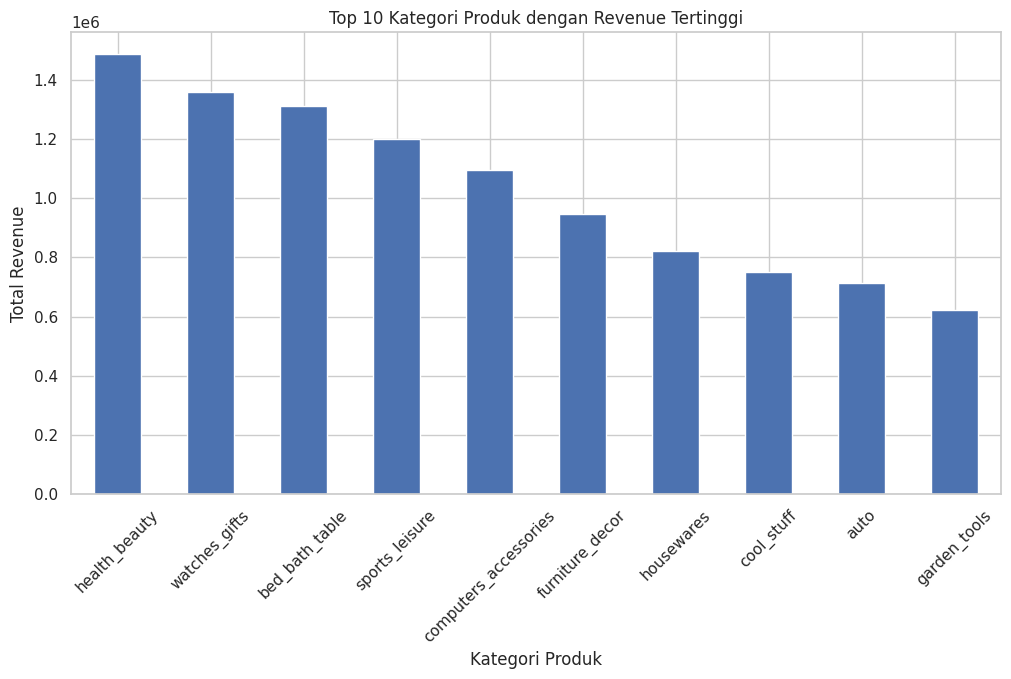

In [20]:
plt.figure(figsize=(12,6))
category_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Kategori Produk dengan Revenue Tertinggi')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

Berdasarkan hasil analisis, kategori *health_beauty* memiliki total revenue tertinggi dibandingkan kategori lainnya, diikuti oleh *watches_gifts* dan *bed_bath_table*.

Selain itu, kategori seperti *computers_accessories* dan *sports_leisure* juga menunjukkan kontribusi revenue yang signifikan.

Sebaliknya, kategori dengan revenue lebih rendah seperti *garden_tools* menunjukkan potensi pasar yang lebih kecil atau frekuensi pembelian yang tidak terlalu sering.

## Q2

Analisis Tren Revenue Bulanan

In [26]:
df_clean = df_clean.dropna(subset=['order_purchase_timestamp'])
df_clean = df_clean.copy()

df_clean['order_month'] = df_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_revenue = df_clean.groupby('order_month')['revenue'].sum().reset_index()

monthly_revenue

,order_month,revenue
0,2016-09,143.46
1,2016-10,48037.38
2,2016-12,19.62
3,2017-01,134950.69
4,2017-02,275654.84
5,2017-03,432021.42
6,2017-04,402322.11
7,2017-05,597427.51
8,2017-06,507508.75
9,2017-07,601794.89


Visualisasi

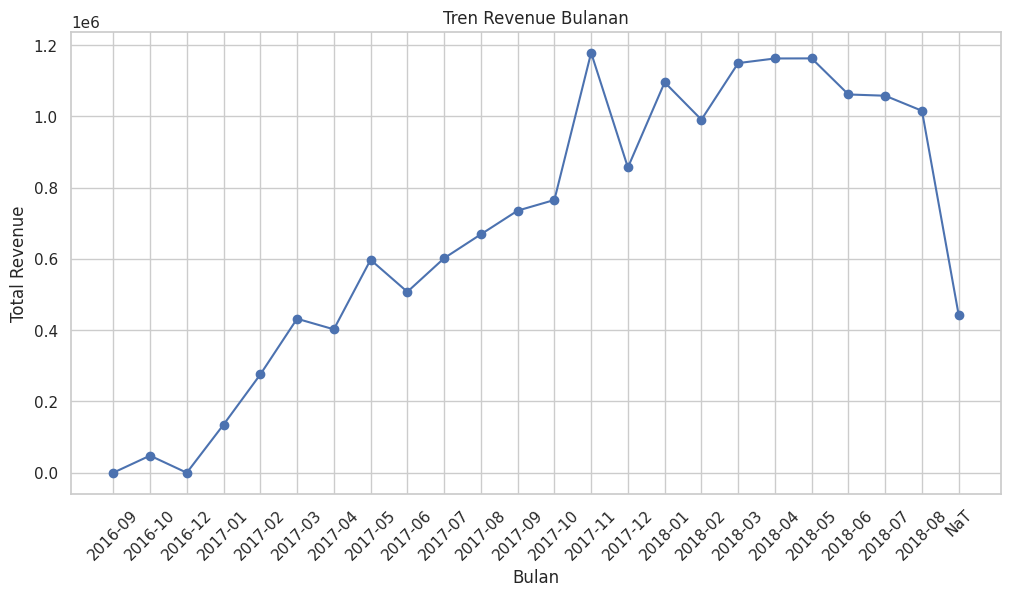

In [22]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['order_month'], monthly_revenue['revenue'], marker='o')
plt.title('Tren Revenue Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## Analisis Lanjutan: RFM Analysis

RFM terdiri dari tiga metrik utama:

- Recency: jumlah hari sejak terakhir kali pelanggan melakukan pembelian.
- Frequency: jumlah transaksi yang dilakukan pelanggan.
- Monetary: total pengeluaran pelanggan.

In [27]:
# Gabungkan data order dengan customer
rfm_df = df_clean.merge(customers_df, on='customer_id', how='left')

# Tentukan tanggal acuan analisis
reference_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Hitung RFM
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'revenue': 'sum'
}).reset_index()

# Rename kolom
rfm.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [28]:
rfm.describe()

,recency,frequency,monetary
count,92079.000000,92079.000000,92079.000000
mean,237.260961,1.033102,172.647450
std,152.585541,0.206886,257.423576
min,1.000000,1.000000,10.070000
25%,114.000000,1.000000,64.000000
50%,218.000000,1.000000,110.080000
75%,346.000000,1.000000,188.295000
max,714.000000,14.000000,13664.080000


Segmentasi sederhana

In [29]:
rfm['recency_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['frequency_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['monetary_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['rfm_score'] = (
    rfm['recency_score'].astype(str) +
    rfm['frequency_score'].astype(str) +
    rfm['monetary_score'].astype(str)
)

rfm.head()

,customer_unique_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


Segmentasi pelanggan

In [30]:
def segment_customer(row):
    if row['recency_score'] >= 4 and row['frequency_score'] >= 4 and row['monetary_score'] >= 4:
        return 'Best Customers'
    elif row['recency_score'] >= 4 and row['frequency_score'] <= 2:
        return 'New Customers'
    elif row['recency_score'] <= 2 and row['frequency_score'] >= 4:
        return 'At Risk Customers'
    elif row['monetary_score'] >= 4:
        return 'High Value Customers'
    else:
        return 'Regular Customers'

rfm['customer_segment'] = rfm.apply(segment_customer, axis=1)

rfm['customer_segment'].value_counts()

,count
customer_segment,
Regular Customers,37740
High Value Customers,18639
New Customers,14791
At Risk Customers,14569
Best Customers,6340


### Visualisasi Segmentasi Pelanggan


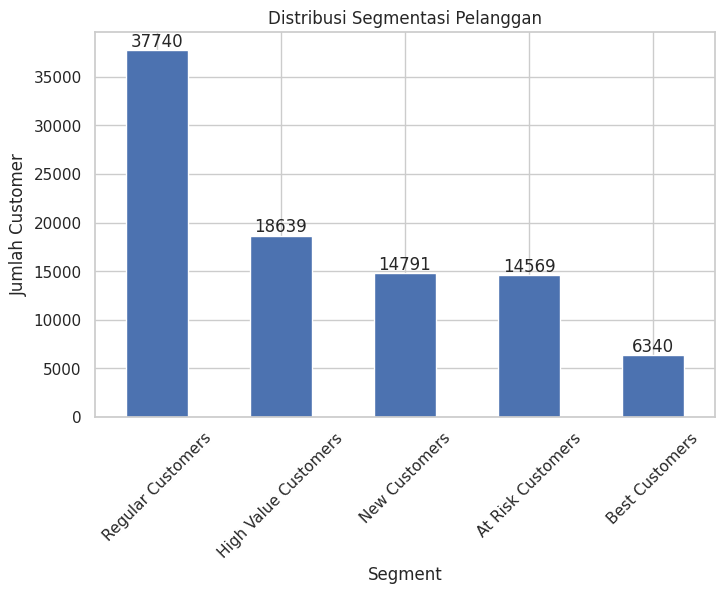

In [32]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap segment + urutkan
segment_counts = rfm['customer_segment'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
bars = segment_counts.plot(kind='bar')

plt.title('Distribusi Segmentasi Pelanggan')
plt.xlabel('Segment')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=45)

# Tambahin label angka di atas bar
for i, value in enumerate(segment_counts):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()
plt.show()

Berdasarkan hasil analisis:

1. Kategori produk dengan revenue tertinggi adalah *health_beauty*, diikuti oleh *watches_gifts* dan *bed_bath_table*.
2. Tren revenue bulanan menunjukkan peningkatan signifikan sepanjang tahun 2017 hingga awal 2018, sebelum mengalami sedikit penurunan.
3. Sebagian besar pelanggan termasuk dalam kategori *Regular Customers*, menunjukkan bahwa mayoritas pelanggan memiliki aktivitas pembelian yang stabil namun tidak terlalu tinggi.
4. Terdapat juga sejumlah pelanggan dalam kategori *Best Customers* dan *High Value Customers* yang berkontribusi besar terhadap revenue perusahaan.
5. Segmentasi ini dapat digunakan untuk strategi pemasaran, seperti memberikan promosi khusus kepada pelanggan bernilai tinggi atau melakukan re-engagement pada pelanggan yang berisiko.

Kesimpulan: Analisis ini memberikan gambaran perilaku pelanggan dan performa penjualan yang dapat digunakan untuk pengambilan keputusan bisnis.

In [33]:
df_clean.to_csv("main_data.csv", index=False)
rfm.to_csv("rfm_data.csv", index=False)